# 16. Which player has the highest winning percentage against top 10 ranked opponents? 

### It imports two libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Matches are recorded with a determined winner and score

In [2]:
IN_DIR = "cleaned_data"

event = pd.read_parquet(f"{IN_DIR}/event.parquet")
ev_ok = event.loc[event["score_ready"]].copy()
print(f"Matches passing quality gate: {len(ev_ok)} / {len(event)} "
      f"({100*len(ev_ok)/len(event):.1f}%)")

Matches passing quality gate: 14413 / 16873 (85.4%)


#### It reads the ID, name, and current rank of the home and away players

In [3]:
home = pd.read_parquet(f"{IN_DIR}/home_team.parquet")[["match_id", "player_id", "full_name", "current_rank"]]
away = pd.read_parquet(f"{IN_DIR}/away_team.parquet")[["match_id", "player_id", "full_name", "current_rank"]]

#### It merges data from major tournaments with player information, then removes potential self-play matches

In [4]:
m = (
    ev_ok[["match_id", "winner_code"]]
    .merge(home, on="match_id", how="inner")
    .merge(away, on="match_id", how="inner", suffixes=("_home", "_away"))
)
m = m[m.player_id_home != m.player_id_away]  # drop self-play (data-error guard)
print("Rows after quality-gated merge:", len(m))

Rows after quality-gated merge: 8785


#### For each match, it creates two rows (one from each player's perspective)
##### containing the opponent's rank and whether that player won and then stacks these two views one below the other

In [5]:
home_rows = pd.DataFrame({
    "player_id": m.player_id_home, "full_name": m.full_name_home,
    "opponent_rank": m.current_rank_away, "is_win": (m.winner_code == 1).astype(int),
})
away_rows = pd.DataFrame({
    "player_id": m.player_id_away, "full_name": m.full_name_away,
    "opponent_rank": m.current_rank_home, "is_win": (m.winner_code == 2).astype(int),
})
long_df = pd.concat([home_rows, away_rows], ignore_index=True)

#### It retains only matches where the opponent had a rank of 10 or lower (current_rank <= 10)
#### then calculates the total number of such matches, the number of wins, and the win percentage for each player

In [6]:
top10 = long_df[long_df.opponent_rank.notna() & (long_df.opponent_rank <= 10)]

agg = top10.groupby("player_id").agg(matches=("is_win", "count"), wins=("is_win", "sum"))
agg["win_pct"] = 100 * agg.wins / agg.matches
agg["full_name"] = top10.groupby("player_id")["full_name"].agg(lambda s: s.value_counts().idxmax())

#### It retains only players with at least three matches against top-10 opponents

In [7]:
result = agg[agg.matches >= 3].sort_values(["win_pct", "matches"], ascending=[False, False])
print(result.head(10))

           matches  wins     win_pct               full_name
player_id                                                   
179146           3     3  100.000000        Kalinskaya, Anna
185388           3     3  100.000000            Humbert, Ugo
228272           3     3  100.000000            Swiatek, Iga
275923           4     3   75.000000         Alcaraz, Carlos
19728            3     2   66.666667         Cirstea, Sorana
89632            3     2   66.666667          Jarry, Nicolas
206570           3     2   66.666667          Sinner, Jannik
23581            6     3   50.000000        Dimitrov, Grigor
67759            4     2   50.000000  Alexandrova, Ekaterina
201239           4     2   50.000000         de Minaur, Alex


#### It plots the top 8 players on a horizontal bar chart in purple (#B284BE); the list order is reversed using `[::-1]` so that the best player appears at the top of the chart, and the win percentage plus the number of matches are displayed next to each bar.

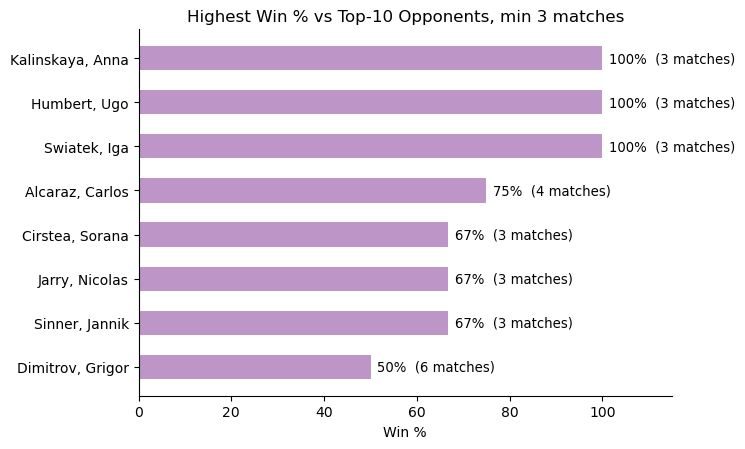

In [8]:
result = agg[agg.matches >= 3].sort_values(["win_pct", "matches"], ascending=[False, False]).head(8)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
names = list(result["full_name"][::-1])
vals = result["win_pct"][::-1]
bars = ax.barh(names, vals, color="#B284BE", alpha=0.85, height=0.55)
for b, v, nm in zip(bars, vals, result["matches"][::-1]):
    ax.text(v + 1.5, b.get_y() + b.get_height() / 2, f"{v:.0f}%  ({nm} matches)", va="center", fontsize=9.5)
ax.set_title("Highest Win % vs Top-10 Opponents, min 3 matches")
ax.set_xlabel("Win %")
ax.set_xlim(0, 115)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("charts/q16_top10_winpct.png", dpi=170)
plt.show()

The three players at the top of the table have each played only three matches. In sports analysis, three matches constitute a small sample size; consequently, the performances of Alcaraz (75% win rate over 4 matches) and Dimitrov (50% over 6 matches) are highly significant in terms of statistical consistency.

The code utilizes the `current_rank` column. This means the opponent's *current* ranking is used as the criterion, rather than the ranking they held at the time the match actually took place.

(As a result, this analysis is not reliable.)